<div align="left" style="background-color: #008080; padding: 20px 10px;">
<h3><b>IDEAS - Institute of Data Engineering, Analytics and Science Foundation</b></h3>
<p>Summer Internship Program 2026</p>
<hr style="width:100%;">
<h3><b>Project Title:</b> Diabetes Prediction: Classification Comparison + Metrics + Evaluation</h3>
<h4>Project Notebook</h4>

<blockquote style="border-left: 4px solid #4285F4; padding-left: 15px;">
  <strong>Created by:</strong> Rounak Biswas<br>
  <strong>Designation:</strong> Software Engineer
</blockquote>
<hr style="width:100%;">
</div>

##  Problem Statement

You are tasked with building a classification model to predict whether a patient has diabetes based on diagnostic measurements.

- Use the **Pima Indian Diabetes Dataset**.
- Compare multiple classification models.
- Evaluate them using accuracy, precision, recall, F1-score, ROC-AUC.


---


##  Dataset Introduction

The dataset contains medical predictor variables and one target variable (`Outcome`).

- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome (0 = No Diabetes, 1 = Diabetes)

### Question 1: Import Libraries and Load Data (2 Marks)

Import `pandas` as `pd` and `numpy` as `np`. Load the Pima Indian Diabetes Dataset `diabetes.csv` from https://drive.google.com/drive/folders/1gieHICVDBbUKMZiSF4YRQMAJic-w50JM?usp=sharing into a pandas DataFrame called `df`. Display the first 5 rows of the DataFrame.

**Expected Output:** A table showing the first 5 rows of the diabetes dataset.

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Question 2: Data Inspection (2 Marks)

Get a quick overview of the dataset. Print the shape of the DataFrame and then check for the total number of missing (null) values across the entire DataFrame.

**Expected Output:** The shape of the DataFrame (e.g., `(768, 9)`) and the total count of null values.

In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Shape: (768, 9)
Total Missing Values: 0


### Question 3: Descriptive Statistics (1 Mark)

Generate the descriptive statistics for the `df` DataFrame to understand the central tendency, dispersion, and shape of the dataset's distribution.

**Hint:** Use the `.describe()` method on the DataFrame.

**Expected Output:** A table showing statistical details like mean, std, min, max, etc., for each numerical column.

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Question 4: Define Feature Matrix and Target Vector (2 Marks)

Prepare the data for modeling by separating it into features (`X`) and the target (`y`). `X` should contain all columns except 'Outcome', and `y` should be the 'Outcome' column. Print the shapes of both `X` and `y`.

**Expected Output:** The shapes of `X` and `y`, which should be `(768, 8)` and `(768,)`.

In [5]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (768, 8)
y Shape: (768,)


### Question 5: Split Data into Training and Testing Sets (2 Marks)

Import `train_test_split` from `sklearn.model_selection`. Split the `X` and `y` data into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`). Use `test_size=0.2`, `random_state=42`, and enable stratification on `y`.

**Expected Output:** No direct output. The variables will be ready for the next steps.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Question 6: Scale the Feature Data (3 Marks)

Import `StandardScaler` from `sklearn.preprocessing`. Create an instance of the scaler, fit it on the training data (`X_train`), and then transform both `X_train` and `X_test`. Store the results in `X_train_scaled` and `X_test_scaled`.

**Expected Output:** No direct output. The scaled data will be stored in new variables.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Question 7: Train and Evaluate a Logistic Regression Model (5 Marks)

Import `LogisticRegression`. Create an instance, train it on the **scaled** training data (`X_train_scaled`, `y_train`), make predictions on the scaled test data, and print the `classification_report`.

**Expected Output:** A text-based classification report showing precision, recall, and f1-score for classes 0 and 1.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



### Question 8: Train and Evaluate a K-Nearest Neighbors (KNN) Model (5 Marks)

Import `KNeighborsClassifier`. Create an instance with `n_neighbors=5`, train it on the scaled training data, make predictions on the scaled test data, and print the `accuracy_score`.

**Expected Output:** A single decimal number representing the accuracy of the KNN model.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.7012987012987013


### Question 9: Train and Evaluate a Support Vector Machine (SVM) Model (5 Marks)

Import `SVC` (Support Vector Classifier). Create an instance with a `kernel='linear'` and `random_state=42`. Train it on the scaled training data, predict on the scaled test data, and print the `f1_score`.

**Expected Output:** A single decimal number representing the F1-score of the SVM model.

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

svm = SVC(kernel='linear', random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM F1 Score:", f1_score(y_test, y_pred_svm))

SVM F1 Score: 0.5656565656565656


### Question 10: Model Comparison with ROC-AUC Score (3 Marks)

Calculate the `roc_auc_score` for all three models (Logistic Regression, KNN, and SVM) using their predictions on the scaled test data. Store the results in a dictionary called `model_scores` where keys are model names ('LogisticRegression', 'KNN', 'SVM') and values are their scores. Print the dictionary. Which model performed best?

**Hint:** Import `roc_auc_score` from `sklearn.metrics`. This score measures a model's ability to distinguish between classes. You will need the predictions you generated in the previous steps.

**Expected Output:** A dictionary showing the name of each model and its corresponding ROC-AUC score. A simple conclusion of which model performed best on performance.

In [11]:
from sklearn.metrics import roc_auc_score

model_scores = {
    "LogisticRegression": roc_auc_score(y_test, y_pred_lr),
    "KNN": roc_auc_score(y_test, y_pred_knn),
    "SVM": roc_auc_score(y_test, y_pred_svm)
}

print(model_scores)

best_model = max(model_scores, key=model_scores.get)

print("\nBest Model:", best_model)
print("Best ROC-AUC Score:", model_scores[best_model])

{'LogisticRegression': np.float64(0.6692592592592593), 'KNN': np.float64(0.6592592592592593), 'SVM': np.float64(0.6742592592592592)}

Best Model: SVM
Best ROC-AUC Score: 0.6742592592592592


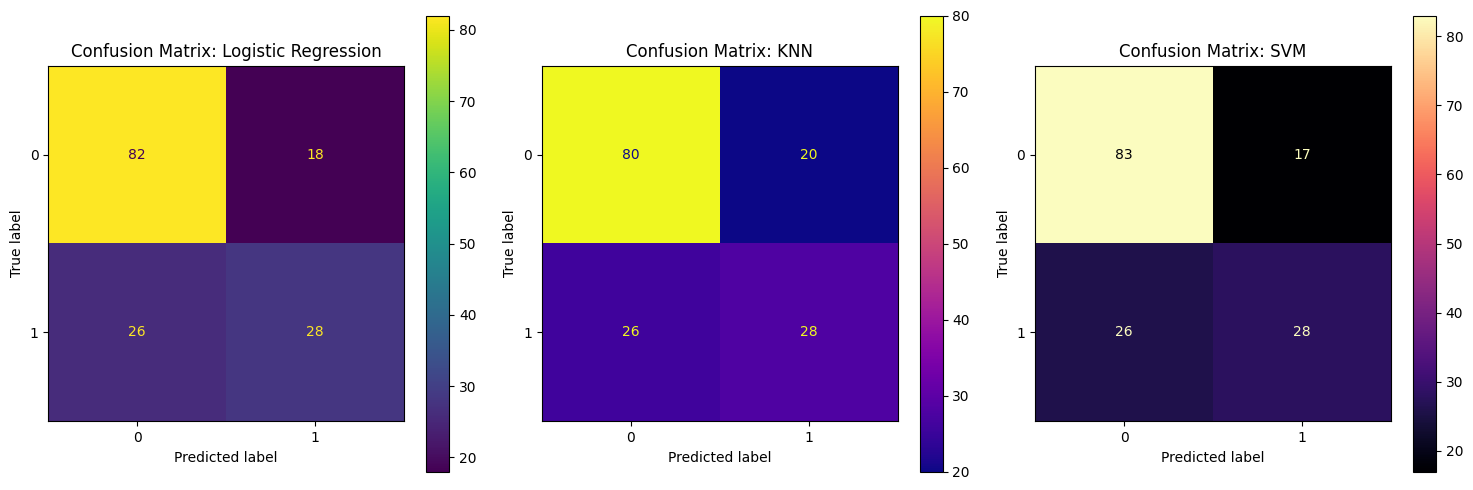

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

plt.figure(figsize=(15, 5))

# Confusion Matrix for Logistic Regression
plt.subplot(1, 3, 1)
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test, cmap='viridis', ax=plt.gca())
plt.title('Confusion Matrix: Logistic Regression')

# Confusion Matrix for KNN
plt.subplot(1, 3, 2)
ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test, cmap='plasma', ax=plt.gca())
plt.title('Confusion Matrix: KNN')

# Confusion Matrix for SVM
plt.subplot(1, 3, 3)
ConfusionMatrixDisplay.from_estimator(svm, X_test_scaled, y_test, cmap='magma', ax=plt.gca())
plt.title('Confusion Matrix: SVM')

plt.tight_layout()
plt.show()

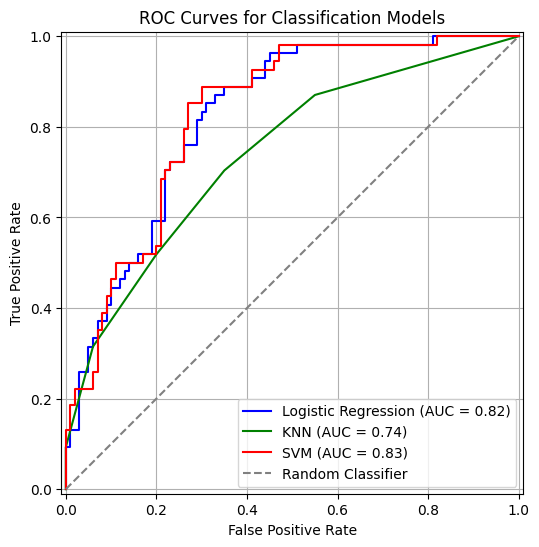

In [15]:
plt.figure(figsize=(8, 6))

# ROC Curve for Logistic Regression
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, name='Logistic Regression', ax=plt.gca(), color='blue')

# ROC Curve for KNN
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test, name='KNN', ax=plt.gca(), color='green')

# ROC Curve for SVM
RocCurveDisplay.from_estimator(svm, X_test_scaled, y_test, name='SVM', ax=plt.gca(), color='red')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.title('ROC Curves for Classification Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Calculate metrics for Logistic Regression
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Calculate metrics for KNN
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

# Calculate metrics for SVM
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# Create a DataFrame to store the metrics
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM'],
    'Accuracy': [acc_lr, acc_knn, acc_svm],
    'Precision': [prec_lr, prec_knn, prec_svm],
    'Recall': [rec_lr, rec_knn, rec_svm],
    'F1-Score': [f1_lr, f1_knn, f1_svm]
})

# Display the DataFrame
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000
1,KNN,0.701299,0.583333,0.518519,0.549020
2,SVM,0.720779,0.622222,0.518519,0.565657
